# Hopfield Network - Question 8
## Energy Minimization with ALL Bits Flipped

**Flipped bits:** All 10 bits (0-9)

**Expected Result:** Network converges to inverted pattern (Spurious Attractor)

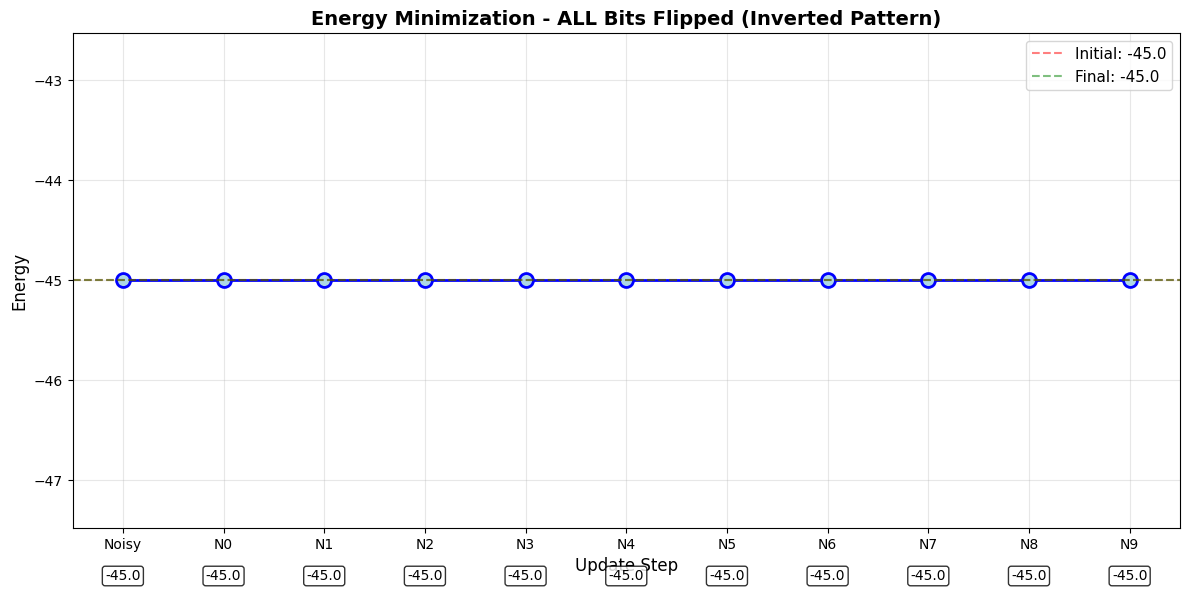

ENERGY ANALYSIS - ALL BITS FLIPPED

Step-by-step energy values:
Step            Energy     Change    
-----------------------------------
Noisy           -45.0      ---       
After N0        -45.0      0         
After N1        -45.0      0         
After N2        -45.0      0         
After N3        -45.0      0         
After N4        -45.0      0         
After N5        -45.0      0         
After N6        -45.0      0         
After N7        -45.0      0         
After N8        -45.0      0         
After N9        -45.0      0         

PATTERN RECOVERY SUMMARY

Target pattern:   [ 1  1  1 -1 -1 -1  1  1 -1 -1]
Noisy input:      [-1 -1 -1  1  1  1 -1 -1  1  1]
Final state:      [-1 -1 -1  1  1  1 -1 -1  1  1]

Initial energy:   -45.00
Final energy:     -45.00
Total reduction:  0.00

Noisy input:  0/10 correct
Final state:  0/10 correct

INVERTED PATTERN CHECK
Inverted pattern: [-1 -1 -1  1  1  1 -1 -1  1  1]
Final state:      [-1 -1 -1  1  1  1 -1 -1  1  1]
Match with inv

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class HopfieldSimple:
    def __init__(self, n_neurons=10):
        self.n_neurons = n_neurons

    def train(self, pattern):
        """Store pattern using Hebbian learning"""
        pattern = pattern.reshape(-1, 1)
        self.weights = np.dot(pattern, pattern.T)
        np.fill_diagonal(self.weights, 0)

    def energy(self, state):
        """Calculate energy of a state"""
        return -0.5 * np.sum(self.weights * np.outer(state, state))

    def update(self, state, neuron):
        """Update single neuron"""
        net_input = np.sum(self.weights[neuron] * state)
        new_state = state.copy()
        new_state[neuron] = 1 if net_input >= 0 else -1
        return new_state

# Create pattern and network
pattern = np.array([1, 1, 1, -1, -1, -1, 1, 1, -1, -1])
noisy = pattern.copy()
noisy[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]] *= -1  # Flip ALL 10 neurons

# Train network
net = HopfieldSimple(10)
net.train(pattern)

# Simulate updates
states = [noisy.copy()]
energies = [net.energy(noisy)]

# Update neurons
for i in range(10):
    new_state = net.update(states[-1], i)
    states.append(new_state)
    energies.append(net.energy(new_state))

# Create visualization
fig, ax = plt.subplots(figsize=(12, 6))

ax.set_title('Energy Minimization - ALL Bits Flipped (Inverted Pattern)', fontsize=14, fontweight='bold')
ax.plot(range(11), energies, 'b-o', linewidth=2, markersize=10,
         markerfacecolor='lightblue', markeredgewidth=2)

# Highlight when energy decreases
for i in range(1, 11):
    if energies[i] < energies[i-1]:
        ax.plot([i-1, i], [energies[i-1], energies[i]], 'g-o',
                linewidth=3, markersize=12, markerfacecolor='green')
        ax.annotate(f'dE = {energies[i]-energies[i-1]:.1f}',
                    xy=(i-0.5, (energies[i-1]+energies[i])/2),
                    xytext=(0, 15), textcoords='offset points',
                    ha='center', fontweight='bold', color='green',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))

# Add grid and labels
ax.grid(True, alpha=0.3)
ax.set_xlabel('Update Step', fontsize=12)
ax.set_ylabel('Energy', fontsize=12)
ax.set_xticks(range(11))
ax.set_xticklabels(['Noisy'] + [f'N{i}' for i in range(10)])

# Add horizontal lines
ax.axhline(y=energies[0], color='red', linestyle='--', alpha=0.5, label=f'Initial: {energies[0]:.1f}')
ax.axhline(y=energies[-1], color='green', linestyle='--', alpha=0.5, label=f'Final: {energies[-1]:.1f}')

# Add energy values
for i, (x, y) in enumerate(zip(range(11), energies)):
    ax.text(x, y-3, f'{y:.1f}', ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

# Print statistics
print("="*60)
print("ENERGY ANALYSIS - ALL BITS FLIPPED")
print("="*60)
print(f"\nStep-by-step energy values:")
print(f"{'Step':<15} {'Energy':<10} {'Change':<10}")
print("-"*35)
for i, e in enumerate(energies):
    if i == 0:
        print(f"{'Noisy':<15} {e:<10.1f} {'---':<10}")
    else:
        change = e - energies[i-1]
        change_str = f"{change:.1f}" if change != 0 else "0"
        print(f"{'After N'+str(i-1):<15} {e:<10.1f} {change_str:<10}")

print("\n" + "="*60)
print("PATTERN RECOVERY SUMMARY")
print("="*60)
print(f"\nTarget pattern:   {pattern}")
print(f"Noisy input:      {noisy}")
print(f"Final state:      {states[-1]}")
print(f"\nInitial energy:   {energies[0]:.2f}")
print(f"Final energy:     {energies[-1]:.2f}")
print(f"Total reduction:  {energies[0] - energies[-1]:.2f}")
print(f"\nNoisy input:  {np.sum(noisy == pattern)}/10 correct")
print(f"Final state:  {np.sum(states[-1] == pattern)}/10 correct")

# Check if it's the inverted pattern
inverted_pattern = -pattern
print(f"\n" + "="*60)
print("INVERTED PATTERN CHECK")
print("="*60)
print(f"Inverted pattern: {inverted_pattern}")
print(f"Final state:      {states[-1]}")
print(f"Match with inverted: {np.sum(states[-1] == inverted_pattern)}/10")